In [4]:
import matplotlib
import pandas as pd
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import glob
import os
from scipy import signal
from scipy import stats
from scipy.stats import spearmanr
import cftime
from datetime import datetime
from dateutil.relativedelta import *
import itertools
import netCDF4
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from cartopy.mpl.geoaxes import GeoAxes
from mpl_toolkits.axes_grid1 import AxesGrid
from matplotlib.colors import BoundaryNorm
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

In [5]:
def get_seasonal_means(ds, seasons):
    ds_season_mean = [ds, ds, ds, ds]
    for i in range(0,len(seasons)):
        season = seasons[i]
        if season == 'DJF':
            ds_season_tmp = ds.where(ds['time.season'] == 'DJF')
            ds_season = ds_season_tmp.rolling(min_periods=3, center=True, time=3).mean()
            ds_season_mean[i] = ds_season.groupby('time.year').mean(dim='time')
        else:
            ds_season = ds.where(ds['time.season'] == season, drop=True)
            ds_season_mean[i] = ds_season.groupby('time.year').mean(dim='time')
    return ds_season_mean

def detrend_1d(y, deg=1):
    x = np.arange(y.size) 
    z = np.polyfit(x, y, deg)  
    trend = np.polyval(z, x)  
    return y - trend + np.mean(y)  # Retain mean after detrending

def detrend_monthly(da, deg=1):
    return da.groupby('time.month').apply(
        lambda x: xr.apply_ufunc(
            detrend_1d, x,
            input_core_dims=[['time']],
            output_core_dims=[['time']],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[float],
            kwargs={'deg': deg}
        )
    )
    
def convert_units(da):
    # Convert Kelvin to Celsius
    if da.attrs.get('units') == 'K':
        da = da - 273.15
        da.attrs['units'] = '°C' 
    
    # Convert Pascal to hectoPascal
    elif da.attrs.get('units') == 'Pa':
        da = da / 100.
        da.attrs['units'] = 'hPa' 

    # Convert kg m-2 s-1 to mm/day
    elif da.attrs.get('units') == 'kg m-2 s-1':
        da = da*86400.
        da.attrs['units'] = 'mm/day' 
    return da

def calcMonAnom(da):
    monclim = da.groupby('time.month').mean('time')
    monanom = da.groupby('time.month') - monclim
    return monanom 

# 1)SAM

In [6]:
## Read PSL for last 200 years

import warnings
warnings.filterwarnings('ignore')

test_run = xr.open_dataset('/g/data/eg3/cxc548/nesp/ACCESS_testing/atmos_fields_junespinup_000-330.nc', decode_times=True).isel(time=slice(-2400, None))
test_run_psl = convert_units(test_run.psl)
esm15_dir = "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/"
esm15_psl = convert_units(xr.open_mfdataset(esm15_dir+"psl/gn/latest/psl_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_*.nc",concat_dim="time",combine="nested").psl.isel(time=slice(-2400, None))).chunk({'time': -1})#, 'lat': 36, 'lon': 64}) 

In [7]:
esm15_psl = esm15_psl.compute()
test_psl_monanom = calcMonAnom(test_run_psl)
esm15_psl_monanom = calcMonAnom(esm15_psl)

test_psl_monanom_dt = detrend_monthly(test_psl_monanom, deg=1)
esm15_psl_monanom_dt = detrend_monthly(esm15_psl_monanom, deg=1)

In [8]:
def calculate_SAM_index(df):
    weights = np.cos(np.deg2rad(df.lat))
    weights.name = "weights"
    # calculate mean at 40°S & 65°S
    S40_zm_psl = (df.weighted(weights)).mean(dim='lon').sel(lat=-40, method='nearest')
    S65_zm_psl = (df.weighted(weights)).mean(dim='lon').sel(lat=-65, method='nearest')
    
    clim_S40 = S40_zm_psl.groupby('time.month').mean('time')
    std_S40 = S40_zm_psl.groupby('time.month').std('time')
    clim_S65 = S65_zm_psl.groupby('time.month').mean('time')
    std_S65 = S65_zm_psl.groupby('time.month').std('time')
    
    # normalise the SAM index
    S40_norm1 = (S40_zm_psl.groupby('time.month') - clim_S40) 
    S40_norm = S40_norm1.groupby('time.month') / std_S40
    S65_norm1 = (S65_zm_psl.groupby('time.month') - clim_S65) 
    S65_norm = S65_norm1.groupby('time.month') / std_S65
    SAM = S40_norm - S65_norm
    SAM = SAM.drop_vars('month')
    return SAM

In [9]:
SAM_test = calculate_SAM_index(test_psl_monanom_dt)
SAM_esm15 = calculate_SAM_index(esm15_psl_monanom_dt)
SAM_obs = xr.open_dataset('/scratch/eg3/gab563/SAM_Marshall_1m_1957-2020.nc', decode_times=True).SAM

In [10]:
test_SAM_seasons = get_seasonal_means(SAM_test, ['DJF', 'MAM', 'JJA', 'SON'])
esm15_SAM_seasons = get_seasonal_means(SAM_esm15, ['DJF', 'MAM', 'JJA', 'SON'])
obs_SAM_seasons = get_seasonal_means(SAM_obs.sel(time=slice('1979','2020')), ['DJF', 'MAM', 'JJA', 'SON'])

test_psl_seasons = get_seasonal_means(test_psl_monanom_dt, ['DJF', 'MAM', 'JJA', 'SON'])
esm15_psl_seasons = get_seasonal_means(esm15_psl_monanom_dt, ['DJF', 'MAM', 'JJA', 'SON'])
psl_obs = xr.open_dataset('/g/data/eg3/gab563/data/ERA5/monthly/msl_ERA5_1m_1959-2022_detrend.nc', decode_times=True).__xarray_dataarray_variable__
obs_psl_seasons = get_seasonal_means(psl_obs.sel(time=slice('1979','2020')), ['DJF', 'MAM', 'JJA', 'SON'])

In [12]:
def linr(a,b):
    slope, intercept, r_value, p_value, std_err = stats.linregress(a,b)
    return slope, p_value
    
def calculate_regression(var_seasons, index_seasons, output_name="ref_var"):
    reg_coefficients = {}
    reg_pvalues = {}
    for season in range(0,4):
        if season == 0:
            index = index_seasons[season][1:] / index_seasons[season][1:].std('year')
            var = var_seasons[season][1:, :, :]
        else:
            index = index_seasons[season] / index_seasons[season].std('year')
            var = var_seasons[season][:, :, :]

        reg_calc = np.apply_along_axis(lambda m: linr(m, index), axis=0, arr=var)       
        reg_coefficients[season] = xr.DataArray(reg_calc[0], coords=[var.lat, var.lon], dims=["lat", "lon"])
        reg_pvalues[season] = xr.DataArray(reg_calc[1], coords=[var.lat, var.lon], dims=["lat", "lon"])
    return reg_coefficients, reg_pvalues

def calculate_regression_ERA5(var_seasons, index_seasons, output_name="ref_var"):
    reg_coefficients = {}
    reg_pvalues = {}
    for season in range(0,4):
        if season == 0:
            index = index_seasons[season][1:] / index_seasons[season][1:].std('year')
            var = var_seasons[season][1:, :, :]
        else:
            index = index_seasons[season] / index_seasons[season].std('year')
            var = var_seasons[season][:, :, :]
        reg_calc = np.apply_along_axis(lambda m: linr(m, index), axis=0, arr=var)
        reg_coefficients[season] = xr.DataArray(reg_calc[0], coords=[var.latitude, var.longitude], dims=["latitude", "longitude"])
        reg_pvalues[season] = xr.DataArray(reg_calc[1], coords=[var.latitude, var.longitude], dims=["latitude", "longitude"])
    return reg_coefficients, reg_pvalues

In [13]:
coeff_test_SAM_psl, pvalues_test_SAM_psl = calculate_regression(test_psl_seasons, test_SAM_seasons)

In [14]:
coeff_esm15_SAM_psl, pvalues_esm15_SAM_psl = calculate_regression(esm15_psl_seasons, esm15_SAM_seasons)

In [16]:
coeff_obs_SAM_psl, pvalues_obs_SAM_psl = calculate_regression_ERA5(obs_psl_seasons, obs_SAM_seasons)

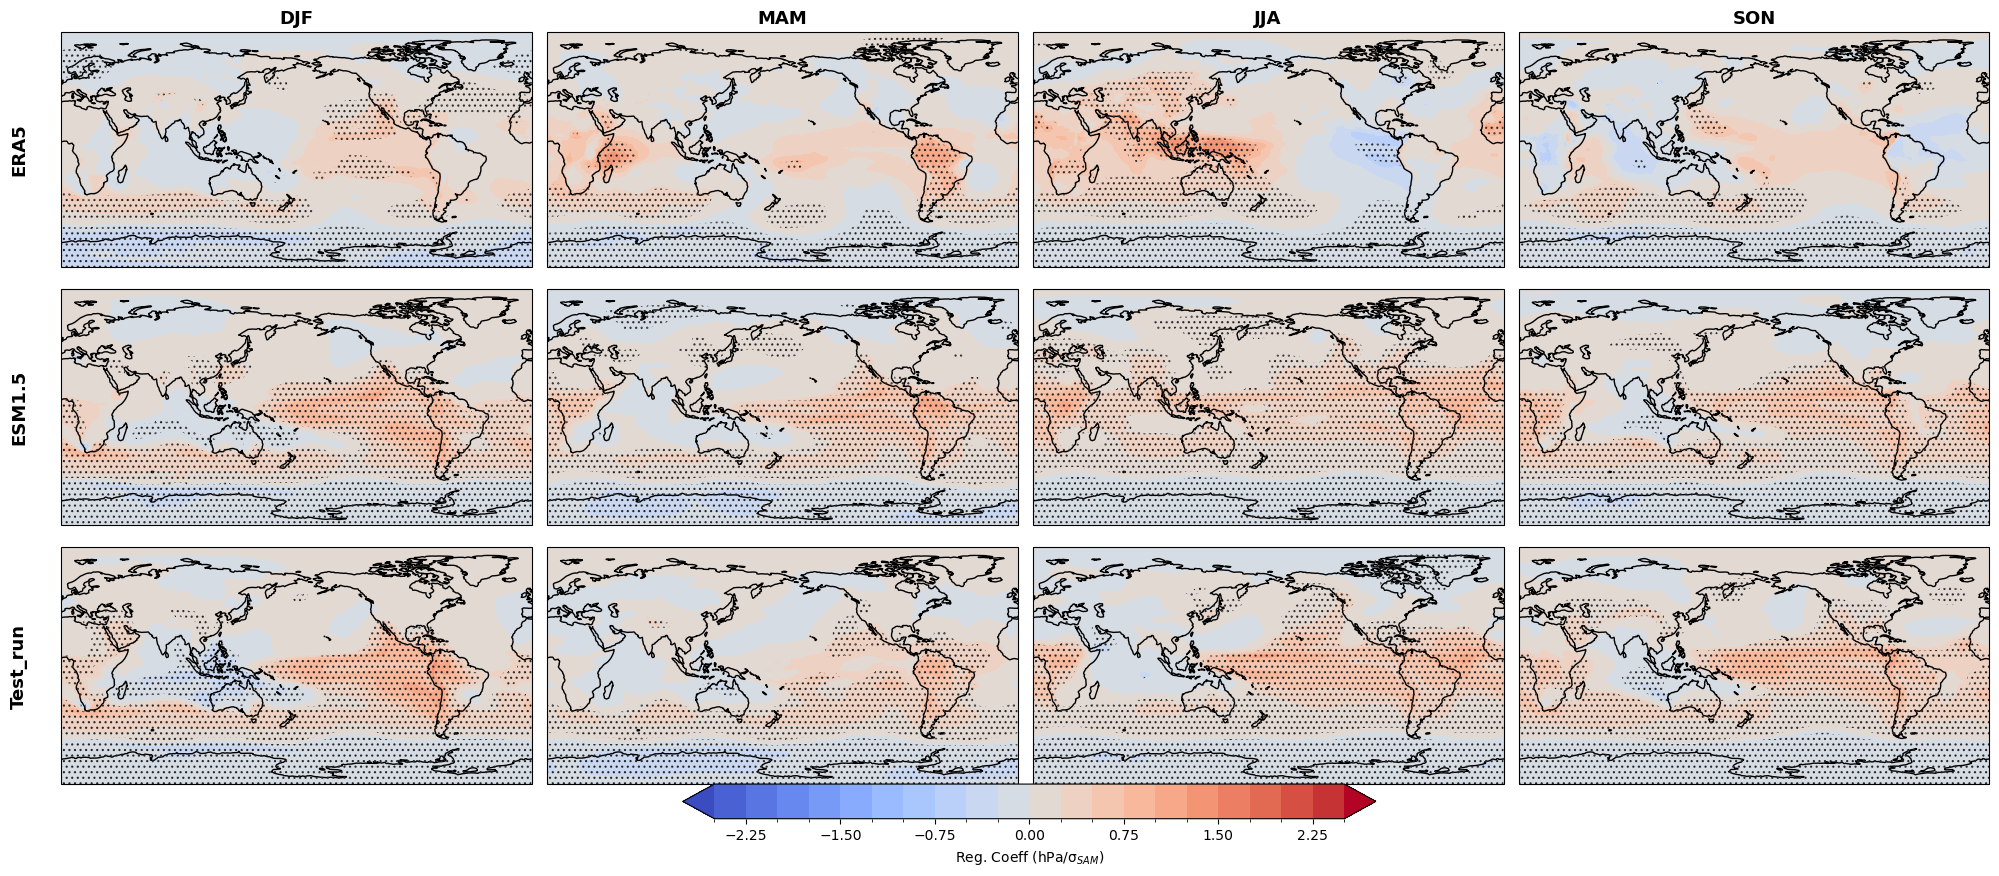

In [32]:
import matplotlib as mpl
mpl.rcParams['hatch.color'] = '#252525'
mpl.rcParams['hatch.linewidth'] = 0.8
hatches = ['...']
seasons = ["DJF", "MAM", "JJA", "SON"]
dataset_labels = ["ERA5", "ESM1.5", "Test_run"]
cmap = 'coolwarm'
vmin, vmax = -2.5, 2.5
levels = np.linspace(vmin, vmax, 21)

coeffs_list = [[100 * coeff_obs_SAM_psl[si].rename({'latitude': 'lat', 'longitude': 'lon'}) for si in range(4)],
               [coeff_esm15_SAM_psl[si] for si in range(4)],
               [coeff_test_SAM_psl[si] for si in range(4)]]
pvals_list = [[pvalues_obs_SAM_psl[si].rename({'latitude': 'lat', 'longitude': 'lon'}).where(pvalues_obs_SAM_psl[si].rename({'latitude': 'lat', 'longitude': 'lon'})<0.05) for si in range(4)],
              [pvalues_esm15_SAM_psl[si].where(pvalues_esm15_SAM_psl[si]<0.05) for si in range(4)],
              [pvalues_test_SAM_psl[si].where(pvalues_test_SAM_psl[si]<0.05) for si in range(4)]]

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 10),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

for row in range(3):
    for col in range(4):
        ax = axes[row, col]
        data = coeffs_list[row][col]
        pvalues = pvals_list[row][col]
        m = data.plot.contourf(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, levels=levels,
                               add_colorbar=False, extend='both')
        ax.contourf(data.lon, data.lat, pvalues, colors='none', hatches=hatches, zorder=2, 
                    transform=ccrs.PlateCarree())
        ax.coastlines()
        if row == 0:
            ax.set_title(f"{seasons[col]}", fontsize=13, fontweight='bold')
        if col == 0:
            ax.text(-0.07, 0.5, dataset_labels[row], va='center', ha='right', fontsize=13, fontweight='bold', 
                    rotation=90, transform=ax.transAxes)

cbar = fig.colorbar(m, ax=axes, orientation='horizontal', fraction=0.045, pad=0.018, label="Reg. Coeff (hPa/σ$_{SAM}$)")
plt.tight_layout(rect=[0, 0.13, 1, 0.96])
plt.show()

# 2) Low-level jet

In [3]:
## Read last 200 years

import warnings
warnings.filterwarnings('ignore')

test_run_u = xr.open_dataset("/g/data/eg3/cxc548/nesp/ACCESS_testing/atmos_fields_junespinup_000-864.nc", decode_times=True).u.sel(pressure=85000, method='nearest').isel(time=slice(-2400, None)).rename({'lat_v':'lat', 'lon_u':'lon'})
esm15_dir = "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/"
esm15_u = xr.open_mfdataset(esm15_dir+"ua/gn/latest/ua_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_*.nc",concat_dim="time",combine="nested").ua.isel(time=slice(-2400, None)).sel(plev=85000, method='nearest')#.chunk({'time': -1})#, 'lat': 36, 'lon': 64}) 

In [4]:
## Detrend

test_u_dt = detrend_monthly(test_run_u)
esm15_u_dt = detrend_monthly(esm15_u.compute())

In [5]:
## Annual and seasonal means

test_u_ann = test_u_dt.groupby('time.year').mean(dim='time')
test_u_seas = get_seasonal_means(test_u_dt,['DJF','MAM','JJA','SON'])
test_run = xr.concat([test_u_ann,test_u_seas[0],test_u_seas[1],test_u_seas[2],test_u_seas[3]], dim='seas')
test_run['seas'] = ['Annual','DJF','MAM','JJA','SON']

esm15_u_ann = esm15_u_dt.groupby('time.year').mean(dim='time')
esm15_u_seas = get_seasonal_means(esm15_u_dt,['DJF','MAM','JJA','SON'])
esm15 = xr.concat([esm15_u_ann,esm15_u_seas[0],esm15_u_seas[1],esm15_u_seas[2],esm15_u_seas[3]], dim='seas')
esm15['seas'] = ['Annual','DJF','MAM','JJA','SON']

In [29]:
import xesmf as xe
u_obs = xr.open_dataset('/scratch/eg3/gab563/u850_ERA5_1m_1979-2021.nc', decode_times=True).u
regridder = xe.Regridder(u_obs, test_run_u, method='bilinear')
u_obs_regridded = regridder(u_obs[:,0,:,:].drop_vars('level'))

In [30]:
obs_u_ann_reg = u_obs_regridded.groupby('time.year').mean(dim='time')
obs_u_seas_rg = get_seasonal_means(u_obs_regridded,['DJF','MAM','JJA','SON'])
observations = xr.concat([obs_u_ann_reg,obs_u_seas_rg[0],obs_u_seas_rg[1],obs_u_seas_rg[2],obs_u_seas_rg[3]], dim='seas')
observations['seas'] = ['Annual','DJF','MAM','JJA','SON']

### Climatology of U850

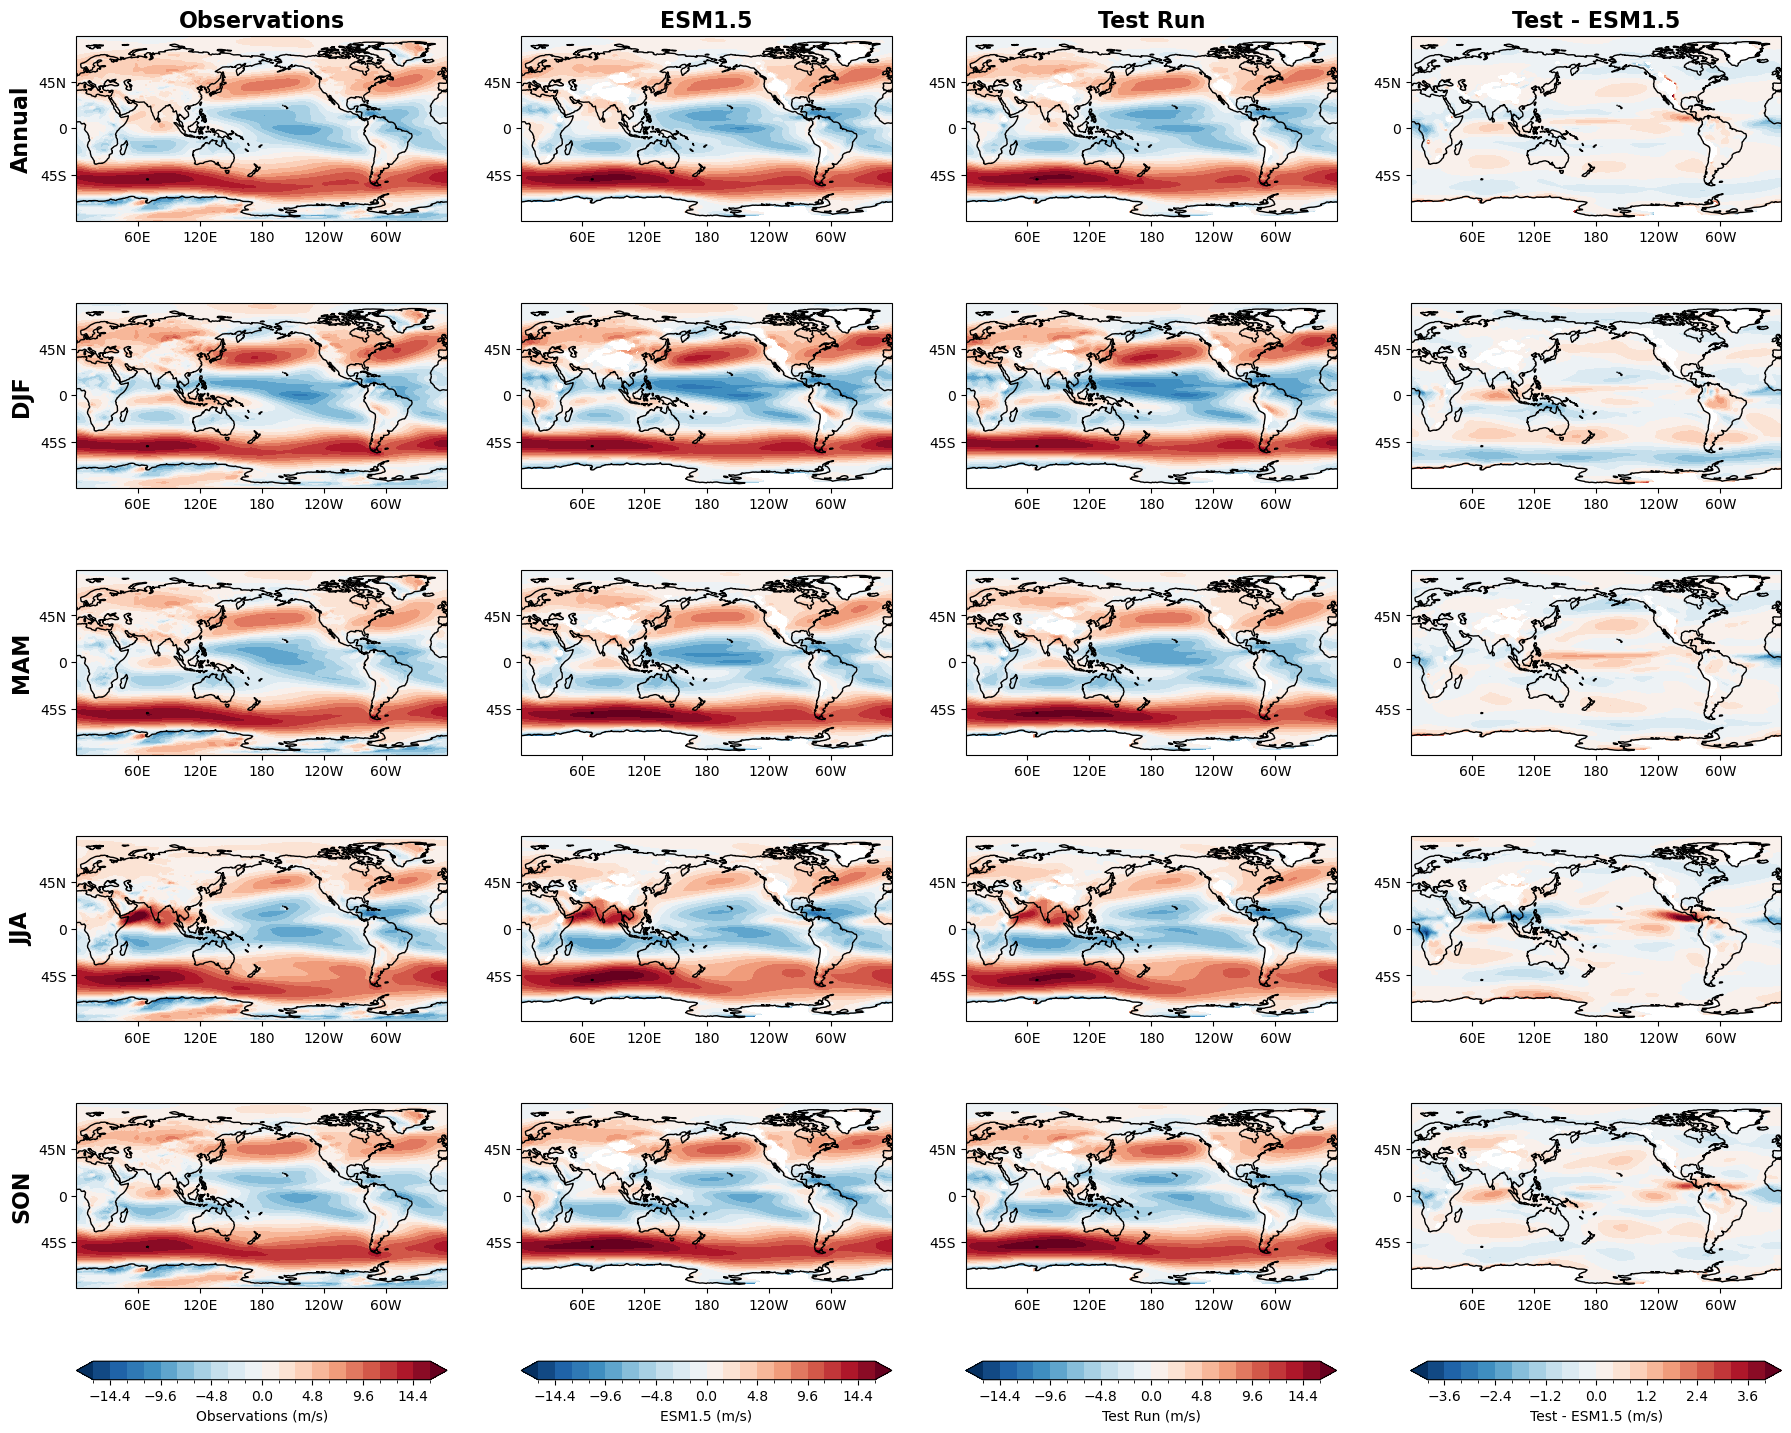

In [43]:
## Plot

cmap = plt.get_cmap('RdBu_r')
vmin_main, vmax_main = -16, 16
vmin_diff, vmax_diff = -4, 4
levels_main = np.linspace(vmin_main, vmax_main, 21)
levels_diff = np.linspace(vmin_diff, vmax_diff, 21)
season_labels = ['Annual', 'DJF', 'MAM', 'JJA', 'SON']
column_titles = ['Observations', 'ESM1.5', 'Test Run', 'Test - ESM1.5']
n_seasons = observations.shape[0]  

fig, ax = plt.subplots(n_seasons, 4, figsize=(22, 18), sharex=True, sharey=True,
    subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)))

ax = ax.reshape(n_seasons, 4)
obs_fields   = [observations[i].mean(dim='year').drop_vars('pressure') for i in range(n_seasons)]
esm_fields   = [esm15[i].mean(dim='year').drop_vars('plev') for i in range(n_seasons)]
run_fields   = [test_run[i].mean(dim='year').drop_vars('pressure') for i in range(n_seasons)]
diff_fields  = [run_fields[i] - esm_fields[i] for i in range(n_seasons)]

fields_per_col = [obs_fields, esm_fields, run_fields, diff_fields]
vmins = [vmin_main, vmin_main, vmin_main, vmin_diff]
vmaxs = [vmax_main, vmax_main, vmax_main, vmax_diff]
levels = [levels_main, levels_main, levels_main, levels_diff]

mappables = [[], [], [], []]

for i in range(n_seasons):
    for j in range(4):
        mappable = fields_per_col[j][i].drop_vars('seas').plot.contourf(ax=ax[i, j], cmap=cmap, vmin=vmins[j], vmax=vmaxs[j], 
                                                      levels=levels[j],add_colorbar=False, extend='both',
                                                      transform=ccrs.PlateCarree())
        mappables[j].append(mappable)
        if i == 0:
            ax[i, j].set_title(column_titles[j], fontsize=16, fontweight='bold')
        if j == 0:
            ax[i, j].set_ylabel(season_labels[i], fontsize=16, fontweight='bold')
        else:
            ax[i,j].set_ylabel('')
for row in ax:
    for axi in row:
        axi.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True, degree_symbol=''))
        axi.yaxis.set_major_formatter(LatitudeFormatter(degree_symbol=''))
        axi.coastlines('110m')
        axi.set_xticks(np.arange(-180, 180, 60))
        axi.set_yticks(np.arange(-90, 90, 45))
        axi.set_xlabel('')

plt.subplots_adjust(wspace=0.2, hspace=0.16, bottom=0.13, top=0.94)

## colorbars
for j in range(4):
    fig.colorbar(mappables[j][0], ax=ax[:, j], orientation='horizontal',fraction=0.06, pad=0.05,
                 label=(column_titles[j] + " (m/s)" if j < 3 else "Test - ESM1.5 (m/s)"))

plt.show()

## Location and intensity of max U850 


In [44]:
def clim_1m_JLI_JSI(zmu, lat_name='lat'):
    months = np.arange(1, 13)
    JLI_list = []
    JSI_list = []
    for month in months:
        month_data = zmu.where(zmu.time.dt.month == month, drop=True)
        # Find index of max along latitude dimension for each time
        JLI = month_data.isel({lat_name: month_data.argmax(dim=lat_name)})[lat_name].mean(dim='time')
        JSI = month_data.max(dim=lat_name).mean(dim='time')
        JLI_list.append(JLI)
        JSI_list.append(JSI)
    JLI_1m = xr.concat(JLI_list, dim='month').assign_coords(month=months)
    JSI_1m = xr.concat(JSI_list, dim='month').assign_coords(month=months)
    return JLI_1m, JSI_1m


In [56]:
## Observations

temp = u_obs_regridded.sel(lat=slice(-85,-40))
obs_u_dt = detrend_monthly(temp)
weights = np.cos(np.deg2rad(obs_u_dt.lat))
weights.name = "weights"
obs_zmu = obs_u_dt.weighted(weights).mean(dim='lon')
JLI_1m_obs, JSI_1m_obs = clim_1m_JLI_JSI(obs_zmu, lat_name='lat')

In [57]:
## Test_run and ESM1.5

weights = np.cos(np.deg2rad(test_u_dt.lat))
weights.name = "weights"
test_zmu = test_u_dt.sel(lat=slice(-85,-40)).weighted(weights).mean(dim='lon')
esm15_zmu = esm15_u_dt.sel(lat=slice(-85,-40)).weighted(weights).mean(dim='lon')
JLI_1m_test, JSI_1m_test = clim_1m_JLI_JSI(test_zmu, lat_name='lat')
JLI_1m_esm15, JSI_1m_esm15 = clim_1m_JLI_JSI(esm15_zmu, lat_name='lat')

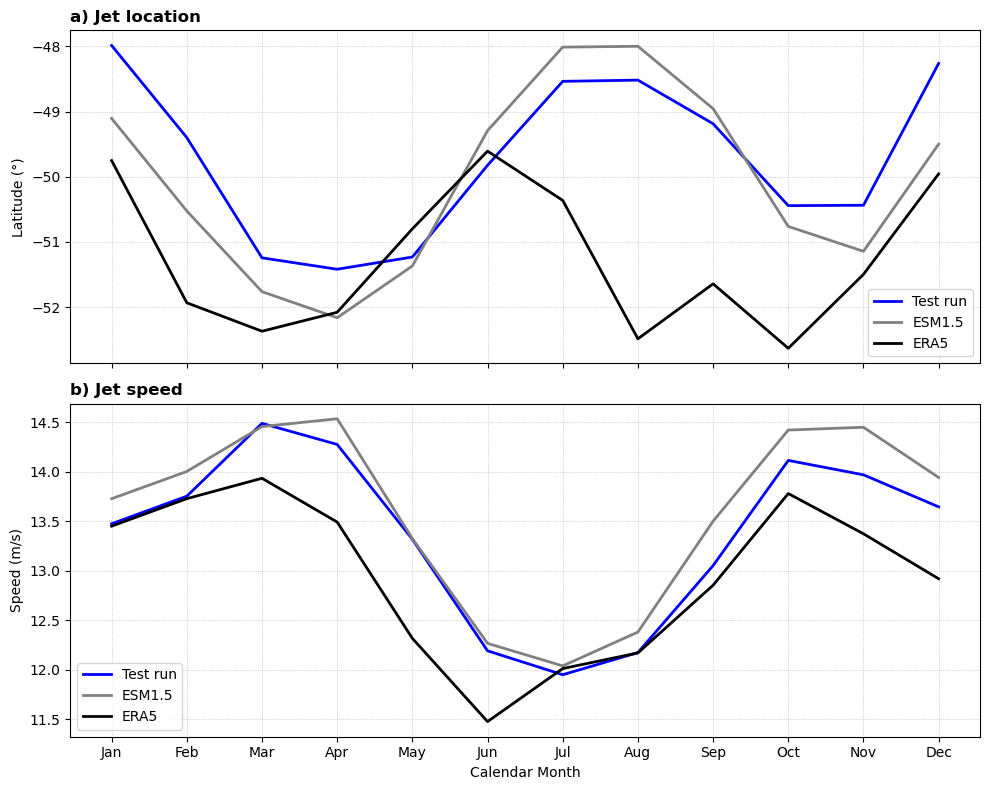

In [58]:
months = [1,2,3,4,5,6,7,8,9,10,11,12]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# -------- Jet location --------
ax[0].plot(JLI_1m_test.month, JLI_1m_test, linewidth=2, color='blue', label='Test run')
ax[0].plot(JLI_1m_esm15.month, JLI_1m_esm15, linewidth=2, color='grey', label='ESM1.5')
ax[0].plot(JLI_1m_obs.month, JLI_1m_obs, color="k", linewidth=2, label="ERA5", linestyle="-")
ax[0].set_title("a) Jet location", loc='left', fontweight='bold')
ax[0].set_ylabel("Latitude (°)")
ax[0].legend()
ax[0].grid(linewidth=0.5, linestyle=':')

# -------- Jet speed --------
ax[1].plot(JSI_1m_test.month, JSI_1m_test, linewidth=2, color='blue', label='Test run')
ax[1].plot(JSI_1m_esm15.month, JSI_1m_esm15, linewidth=2, color='grey', label='ESM1.5')
ax[1].plot(JSI_1m_obs.month, JSI_1m_obs, color="k", linewidth=2, label="ERA5", linestyle="-")
ax[1].set_title("b) Jet speed", loc='left', fontweight='bold')
ax[1].set_xlabel("Calendar Month")
ax[1].set_ylabel("Speed (m/s)")
ax[1].set_xticks(months)
ax[1].set_xticklabels(month_labels)
ax[1].legend()
ax[1].grid(linewidth=0.5, linestyle=':')

plt.tight_layout()
plt.show()
